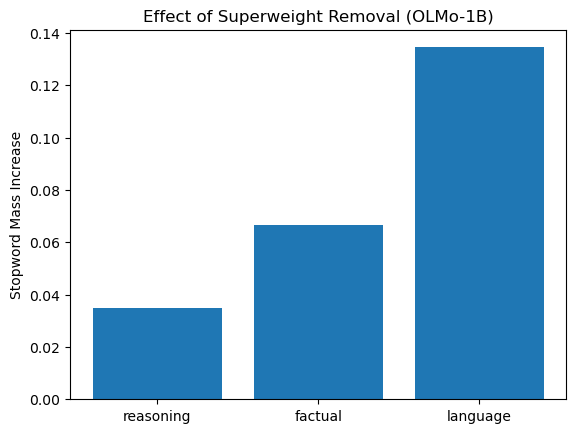

In [3]:
import json
import matplotlib.pyplot as plt

path = "../../results/stopword_experiments/olmo1b_sw_l1_1764_1710.json"

with open(path) as f:
    data = json.load(f)

cats = data["summary_by_category"]

names = []
deltas = []

for k, v in cats.items():
    names.append(k)
    deltas.append(v["stopword_mass_delta"]["mean"])

plt.bar(names, deltas)
plt.ylabel("Stopword Mass Increase")
plt.title("Effect of Superweight Removal (OLMo-1B)")
plt.show()

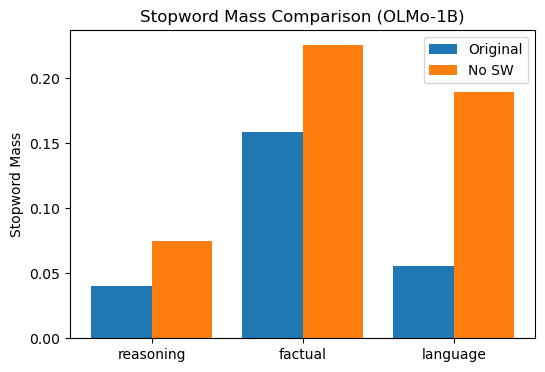

In [4]:
orig = []
ablt = []

for k, v in cats.items():
    orig.append(v["stopword_mass_orig"]["mean"])
    ablt.append(v["stopword_mass_ablt"]["mean"])

x = range(len(names))

plt.figure(figsize=(6,4))
plt.bar(x, orig, width=0.4, label="Original")
plt.bar([i+0.4 for i in x], ablt, width=0.4, label="No SW")

plt.xticks([i+0.2 for i in x], names)
plt.ylabel("Stopword Mass")
plt.title("Stopword Mass Comparison (OLMo-1B)")
plt.legend()
plt.show()

## Math Experiment

In [5]:
import json

path = "../../results/math_experiments/olmo1b_math_sw_l1_1764_1710.json"

with open(path) as f:
    data = json.load(f)

summary_all = data["summary_all"]
summary_by_cat = data["summary_by_category"]

print("=== GLOBAL SUMMARY ===")
for k, v in summary_all.items():
    if isinstance(v, dict) and "mean" in v:
        print(f"{k}: {v['mean']:.4f}")

print("\n=== BY CATEGORY ===")
for cat, stats in summary_by_cat.items():
    print(f"\n[{cat}]")
    print(f"correct_prob_delta: {stats['correct_prob_delta']['mean']:.4f}")
    print(f"rank_orig: {stats['correct_rank_orig']['mean']:.2f}")
    print(f"rank_ablt: {stats['correct_rank_ablt']['mean']:.2f}")

=== GLOBAL SUMMARY ===
correct_prob_orig: 0.1117
correct_prob_ablt: 0.0067
correct_prob_delta: -0.1050
digit_mass_orig: 0.5296
digit_mass_ablt: 0.3022
digit_mass_delta: -0.2274
stopword_mass_orig: 0.0314
stopword_mass_ablt: 0.0768
stopword_mass_delta: 0.0454
entropy_orig: 3.6502
entropy_ablt: 5.5505
entropy_delta: 1.9003
kl_orig_to_ablt: 1.7476
kl_ablt_to_orig: 2.2957
correct_rank_orig: 4.4211
correct_rank_ablt: 36.3158

=== BY CATEGORY ===

[arithmetic]
correct_prob_delta: -0.0390
rank_orig: 5.50
rank_ablt: 30.12

[multiplication]
correct_prob_delta: -0.2021
rank_orig: 3.17
rank_ablt: 65.17

[word_math]
correct_prob_delta: -0.0940
rank_orig: 4.20
rank_ablt: 11.60


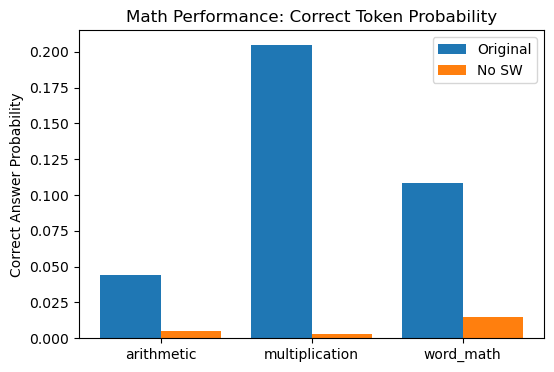

In [6]:
import matplotlib.pyplot as plt

cats = summary_by_cat

names = []
orig = []
ablt = []

for k, v in cats.items():
    names.append(k)
    orig.append(v["correct_prob_orig"]["mean"])
    ablt.append(v["correct_prob_ablt"]["mean"])

x = range(len(names))

plt.figure(figsize=(6,4))
plt.bar(x, orig, width=0.4, label="Original")
plt.bar([i+0.4 for i in x], ablt, width=0.4, label="No SW")

plt.xticks([i+0.2 for i in x], names)
plt.ylabel("Correct Answer Probability")
plt.title("Math Performance: Correct Token Probability")
plt.legend()
plt.show()

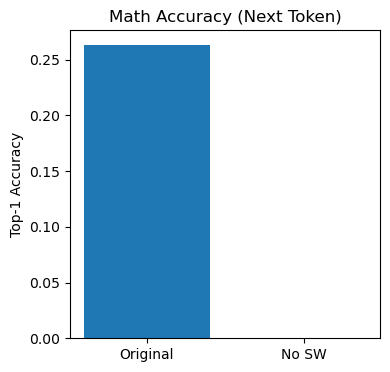

Original: 0.263
No SW: 0.000


In [7]:
orig_acc = summary_all["top1_correct_orig_rate"]
ablt_acc = summary_all["top1_correct_ablt_rate"]

plt.figure(figsize=(4,4))
plt.bar(["Original", "No SW"], [orig_acc, ablt_acc])
plt.ylabel("Top-1 Accuracy")
plt.title("Math Accuracy (Next Token)")
plt.show()

print(f"Original: {orig_acc:.3f}")
print(f"No SW: {ablt_acc:.3f}")

In [8]:
print(prompt)
print("orig top10:", row["top10_orig"])
print("ablt top10:", row["top10_ablt"])

NameError: name 'prompt' is not defined